In [ ]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict , Annotated
from langchain_core.messages import HumanMessage ,SystemMessage , BaseMessage
from langchain_groq import ChatGroq
from langgraph.graph.message import add_messages #reducer fn to add message instead of replace(same as operator.add, but more optimized)
from langgraph.checkpoint.memory import MemorySaver #stored in RAM

In [2]:
pip install langchain_groq

  Using cached langchain_groq-1.1.3-py3-none-any.whl.metadata (2.9 kB)
  Using cached groq-0.37.1-py3-none-any.whl.metadata (16 kB)
Using cached langchain_groq-1.1.3-py3-none-any.whl (20 kB)
Using cached groq-0.37.1-py3-none-any.whl (137 kB)

   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
llm = ChatGroq(model="llama-3.1-8b-instant")

In [16]:
class ChatState(TypedDict):
    messages : Annotated[list[BaseMessage] ,add_messages] #human, ai ,tool and system messg collectively called basemessage
    
def chat_node(state : ChatState):
    messages = state['messages']
    
    result = llm.invoke(messages)
    
    return { 'messages': [result]}
     

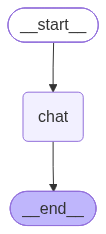

In [20]:
graph = StateGraph(ChatState)
checkpoint = MemorySaver()

graph.add_node('chat' , chat_node)

graph.add_edge(START , 'chat')
graph.add_edge('chat' , END)

chatbot = graph.compile(checkpointer= checkpoint)
chatbot

In [19]:
thread_id = "1"
while True:
    user_message = input('type here :')
    print('USER : ' , user_message)
    
    if user_message.strip().lower() in ['exit' , 'end' ,'bye']:
        break
    
    config = {'configurable': {'thread_id' : thread_id}}
    result = chatbot.invoke({'messages': [HumanMessage(content= user_message) , SystemMessage("you are a financial expert")]} , config= config)
    print('AI:' , result['messages'][-1].content)

USER :  hi
AI: Hello. How can I assist you today? Are you seeking advice on investments, retirement planning, or perhaps you have questions about personal finance management?
USER :  my name is akshat
AI: Nice to meet you, Akshat. I'm here to help with any financial questions or concerns you may have. What's been on your mind lately when it comes to your finances? Do you have a specific goal in mind, such as saving for a big purchase or paying off debt?
USER :  what is EBITA
AI: EBITA stands for Earnings Before Interest, Taxes, and Amortization. It's a financial metric used to evaluate a company's profitability and cash flow generation.

EBITA is calculated by adding back interest and taxes to a company's net income, and also adding back the amortization of intangible assets. The formula for EBITA is:

EBITA = Net Income + Interest + Taxes + Amortization

EBITA is often used by investors and analysts to assess a company's ability to generate cash and pay off debts. It's also considered